In [2]:
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt

In [3]:
mnist = keras.datasets.mnist
(x_train_full, y_train_full), (x_test, y_test) = keras.datasets.mnist.load_data()


In [4]:
x_train_full.shape

(60000, 28, 28)

In [5]:
x_test.shape

(10000, 28, 28)

In [6]:
x_train_full[1] # show the first cell/ raw pixel values of one image

array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,  51, 159, 253, 159,  50,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,  48, 238, 252, 252, 252, 237,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  

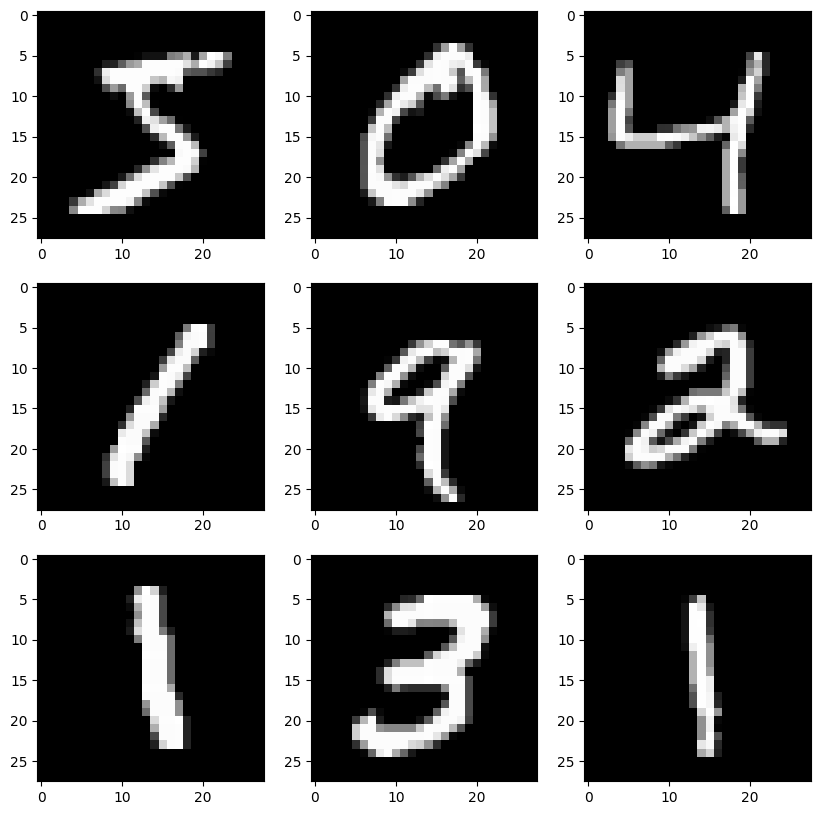

In [7]:
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(10, 10))
a = 0

for i in range(3):
    for j in range(3):
        axes[i, j].imshow(x_train_full[a], cmap=plt.get_cmap('gray'))
        a += 1
plt.show()

In [10]:
# This is when we do normilization happens
# We can see that our data ranges from (0-255) inidicating
# wether the pixel is black or white, 
# so we just scale that to the range [0, 1] instead of [0, 255]
# cuz that would be easier to deal with, when we calculate activation funcctions and gradients

In [8]:
x_valid, x_train = x_train_full[:5000] / 255, x_train_full[5000:] / 255
y_valid, y_train = y_train_full[:5000], y_train_full[5000:]
x_text = x_test / 255

In [9]:
x_train[1] # or x_valid[1]

array([[0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.    

In [10]:
y_valid, y_train

(array([5, 0, 4, ..., 2, 1, 2], shape=(5000,), dtype=uint8),
 array([7, 3, 4, ..., 5, 6, 8], shape=(55000,), dtype=uint8))

In [15]:
# Next: Define the class names

In [11]:
class_names = ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']

In [12]:
 y_train[100] # looking at the value of the first y train/ or do class_names[y_train[0]

np.uint8(7)

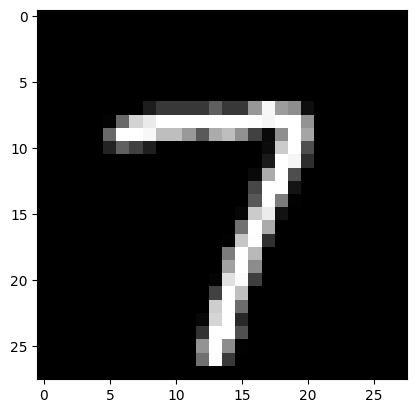

In [13]:
plt.imshow(x_train[100], cmap=plt.get_cmap('gray'))

In [ ]:
## Train the model

In [17]:
model = keras.models.Sequential() # building a model from keras
# adding them layers
model.add(keras.layers.Flatten(input_shape = [28, 28])) # flatten up the input

# the hidden layers
model.add(keras.layers.Dense(300, activation = 'relu')) # 1st hidden layer
model.add(keras.layers.Dense(100, activation = 'relu')) # 2nd hidden layer
model.add(keras.layers.Dense(10, activation = 'softmax')) # output layer with 10 label (neurons)



In [19]:
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_2 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 300)            │       235,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 100)            │        30,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 266,610 (1.02 MB)

 Trainable params: 266,610 (1.02 MB)

 Non-trainable params: 0 (0.00 B)

In [20]:
model.layers

[<Flatten name=flatten_2, built=True>,
 <Dense name=dense_1, built=True>,
 <Dense name=dense_2, built=True>,
 <Dense name=dense_3, built=True>]

In [21]:
# compile the model, choose loss function ,optimizer and metrics
model.compile(loss='sparse_categorical_crossentropy', optimizer='sgd', metrics=['accuracy'])